In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [4]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/10xpbmc5/10xpbmc5_symbol.h5ad"
#path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/10xpbmc5/10xpbmc5_id.h5ad"

### Step 1: Prep data

In [5]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
#adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata = adata.copy()

# Remove unmapped genes
#adata.var.index = adata.var["gene_id"]
adata.var.index = adata.var["gene_name"]
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
#adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

In [6]:
# Prep data for cell2sentence 
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="c2s", organism="Homo Sapiens")

In [7]:
adata.obs["broad_type"].value_counts()

broad_type
T cells      5334
Monocytes    3204
B cells       960
NK cells      469
DC            166
HSC            34
Name: count, dtype: int64

In [8]:
adata

AnnData object with n_obs × n_vars = 10167 × 36581
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Percent_mito', 'qc', 'RNA_snn_res.0.1', 'seurat_clusters', 'symphony_type', 'manual_type', 'broad_type', 'ident', 'organism', 'cell_type', 'tissue', 'sex', 'batch_condition'
    var: 'gene_name', 'gene_id'

### Step 2: Create pseudobulk

In [9]:
# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = generate_pseudobulk(adata = adata,
                                             cell_type_col = "broad_type",
                                             n_pseudobulks = 250,
                                             target_proportion_min = 0.1,
                                             target_proportion_max = 0.80, 
                                             n_cells_per_pseudobulk = 30, 
                                             random_state = 42 
                                            )

### Step 3: Create signature matrix

In [10]:
# Create signature matrix from single cell data
sig_mat = create_signature_matrix(adata = adata,
                                  sample_col = "orig.ident", # sample id column
                                  celltype_col = "broad_type",
                                  groupby = "broad_type",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

### Step 4: Extract Embeddings

In [11]:
from embeddings import *

geneformer is not installed. Skipping related functions.
cell2sentence is not installed. Skipping related functions.
cellhermes successfully imported.
scGPT is not installed. Skipping related functions.
scVI is not installed. Skipping related functions.


In [12]:
from deconvolution import *

<h4 style="color:blue">Geneformer</h4>

In [13]:
sig_mat_gf_embed = extract_embs(
    bulk_df = sig_mat,
    mode = "geneformer", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    delete_temp_files = True
)

In [14]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, 
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    delete_temp_files = True
)

In [15]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, 
                            signature_df = sig_mat_gf_embed.T, 
                            normalize = True)

<h4 style="color:blue">PCA</h4>

In [16]:
# Extract embeddings 
bulk_sig_mat_pc = extract_components(bulk_df = pseudo_bulk,
                                     sig_mat = sig_mat,
                                     mode = "pca",
                                     transform = True)

bulk_pc = bulk_sig_mat_pc["pca_bulk"]
sig_mat_pc = bulk_sig_mat_pc["sig_pca"]

In [17]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = bulk_pc.T, 
                            signature_df = sig_mat_pc.T, 
                            normalize = True)

<h4 style="color:blue">scVI</h4>

In [18]:
sig_mat_scvi_embed = extract_embs(
    bulk_df = sig_mat, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

In [19]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

In [20]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_scvi_embed.T, 
                            normalize = True)

<h4 style="color:blue">Counts</h4>

In [21]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk.T,
                            signature_df = sig_mat.T,
                            normalize = True)

<h4 style="color:blue">scGPT</h4>

In [22]:
sig_mat_scgpt_embed = extract_embs(
    bulk_df = sig_mat, 
    mode = "scgpt", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/scGPT-0.2.4/models/scGPT_human",
    delete_temp_files = True 
)

In [23]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk,
    mode = "scgpt", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/scGPT-0.2.4/models/scGPT_human",
    delete_temp_files = True 
)

In [24]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, 
                            signature_df = sig_mat_scgpt_embed.T,
                            normalize = True)

<h4 style="color:blue">Cell2Sentence</h4>

In [25]:
sig_mat_c2s_embed = extract_embs(
    bulk_df = sig_mat, 
    mode = "c2s", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/C2S-Pythia-410m-cell-type-prediction/", 
    delete_temp_files = True
)

In [26]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "c2s",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/C2S-Pythia-410m-cell-type-prediction/", 
    delete_temp_files = True
)

In [27]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_c2s_embed.T, 
                            normalize = True)

<h4 style="color:blue">CellHermes</h4>

In [28]:
sig_mat_ch_embed = extract_embs(
    bulk_df = sig_mat, 
    mode = "cellhermes", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes", 
    delete_temp_files = True)

In [29]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, 
    mode = "cellhermes",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes", 
    delete_temp_files = True
)

In [30]:
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_ch_embed.T, 
                            normalize = True)

### Step 5: Visualize Results

In [31]:
# Import associated modules
from visualization import *

In [32]:
res_df = load_results(folder_path = '../results/pbmc10x/',
                      ground_truth_file = '../results/pbmc10x/pseudobulk_true_proportions.csv')

# Drop ground truth results 
res_df = res_df[res_df.Model != "pseudobulk"]

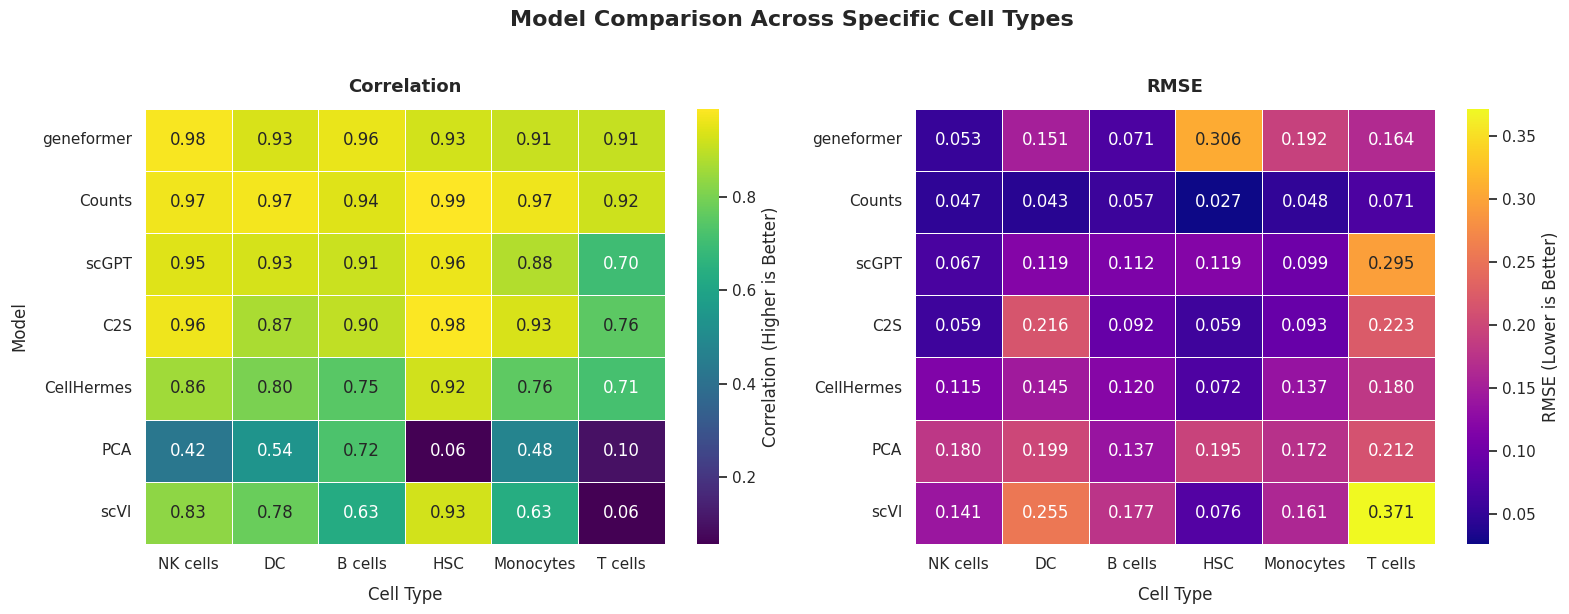

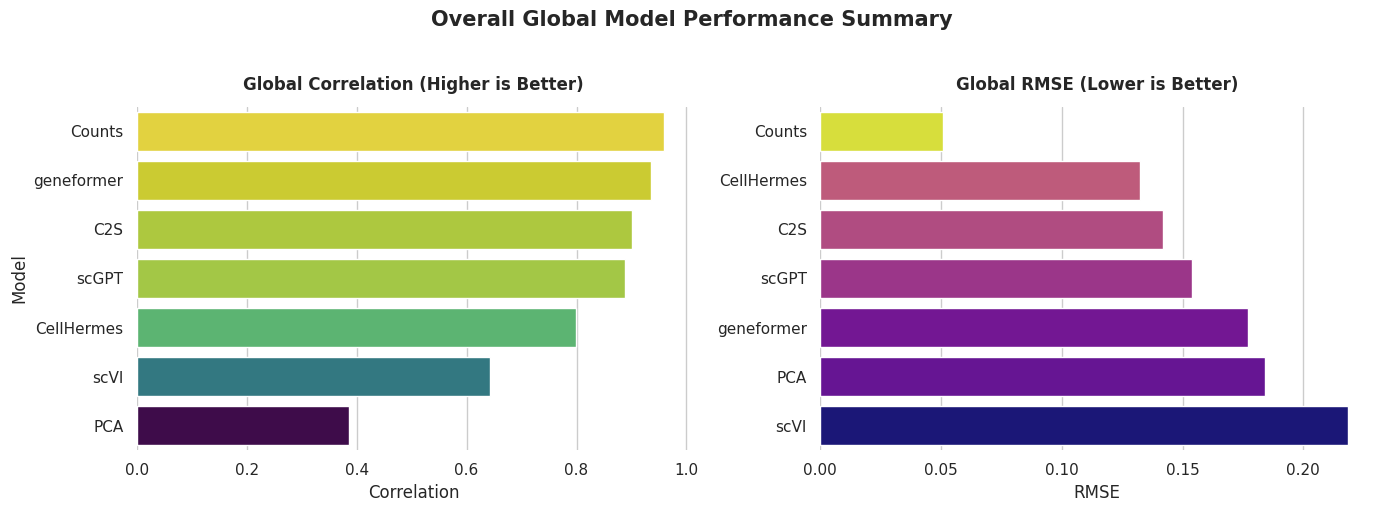

In [33]:
# Remove global correlations/RMSEs
res_df_cell_type = res_df[res_df['CellType'] != 'Global'].copy()
res_df_global = res_df[res_df['CellType'] == 'Global'].copy()

# Plot
plot_cell_type_heatmaps(res_df_cell_type)
plot_global_comparison(res_df_global)